# Algo 3: Unified Inference with Disentangled Rejection
# Experiment: Auto LR + ForwardCache
## BoT-IoT | Day-23 FROZEN Checkpoint | Recalibrate q | Analytic $L_\varphi$ (R/2)
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from pennylane import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

In [2]:
from scripts.cache import (
    ForwardCache,
    cached_class_conditional_calibrate,
    cached_nonconformity_scores,
    cached_per_class_far,
    cached_predict_labels,
    cached_qsnet_infer,
    cached_qsnet_infer_per_class,
    conformal_alpha_sweep_from_scores,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.conformal import threshold_from_scores
from scripts.constants import (
    DEFAULT_ALPHA,
    DEFAULT_BATCH_SIZE,
    DEFAULT_CF,
    DEFAULT_NOISE_RATE,
    ZERO_DAY,
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
    stratified_head,
    to_angles,
)
from scripts.logging import write_history_log
from scripts.theory import analytic_lipschitz_bound, clopper_pearson_ci
from scripts.utils import get_torch_device, to_np_y

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Config

In [4]:
NOTEBOOK_NAME = "4class-3000each-lr0.01auto-algo3-cached"
DAY23_NOTEBOOK = "4class-3000each-lr0.01auto-maqt"

dataset = "BoT-IoT"
target_col = "label_multiclass"
data_path = f"data/FROZEN/{dataset}"
frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

SEED = 42

## Load Team C's FROZEN Features

In [5]:
handoff = json.loads(Path(frozen_feat_path).read_text())
FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Team C selector: QIGPSO
k=10 features: ['n_pkts_total', 'n_bytes_total', 'src_bytes', 'rate', 'pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'pkt_size_std', 'protocol', 'conn_state']


## Load Team A's FROZEN Dataset

In [6]:
# load all data
X_train_full, y_train_full, class_names, df_train = load_split(
    data_path,
    "train",
    target_col,
    categories=None,
    csv=True,
    selected_cols=FEATURE_COLS,
    return_df=True,
)
X_cal_full, y_cal_full, _, df_cal = load_split(
    data_path,
    "calibration",
    target_col,
    categories=class_names,
    csv=True,
    selected_cols=FEATURE_COLS,
    return_df=True,
)
X_test_full, y_test_full, _, df_test = load_split(
    data_path,
    "test",
    target_col,
    categories=class_names,
    csv=True,
    selected_cols=FEATURE_COLS,
    return_df=True,
)
X_zero_full, y_zero_full, _, df_zero = load_split(
    data_path,
    "zeroday",
    target_col,
    categories=None,
    csv=True,
    selected_cols=FEATURE_COLS,
    return_df=True,  # categories must be None for zeroday set
)

# check shape
print(
    f"train   : {X_train_full.shape, y_train_full.shape}\n\
cal     : {X_cal_full.shape, y_cal_full.shape}\n\
test    : {X_test_full.shape, y_test_full.shape}\n\
zero    : {X_zero_full.shape, y_zero_full.shape}\n\
classes : {class_names}\n"
)

df_train.head(3)

train   : ((148729, 10), (148729,))
cal     : ((18591, 10), (18591,))
test    : ((18591, 10), (18591,))
zero    : ((683, 10), (683,))
classes : ['DDoS', 'DoS', 'Normal', 'Reconnaissance']



,n_pkts_total,n_bytes_total,src_bytes,rate,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,protocol,conn_state,label_multiclass
0,-0.262256,-0.798644,-0.774964,-0.356930,0.000000,0.123458,-0.266091,0.827772,0.0,0.0,DoS
1,0.427561,-0.121016,0.000000,-0.123704,0.000000,0.120431,0.030826,0.766490,0.0,0.0,DoS
2,0.768961,0.200956,0.368220,1.725276,0.761987,0.244690,0.422755,0.618673,0.0,0.0,DDoS


## EDA (Before Subset)

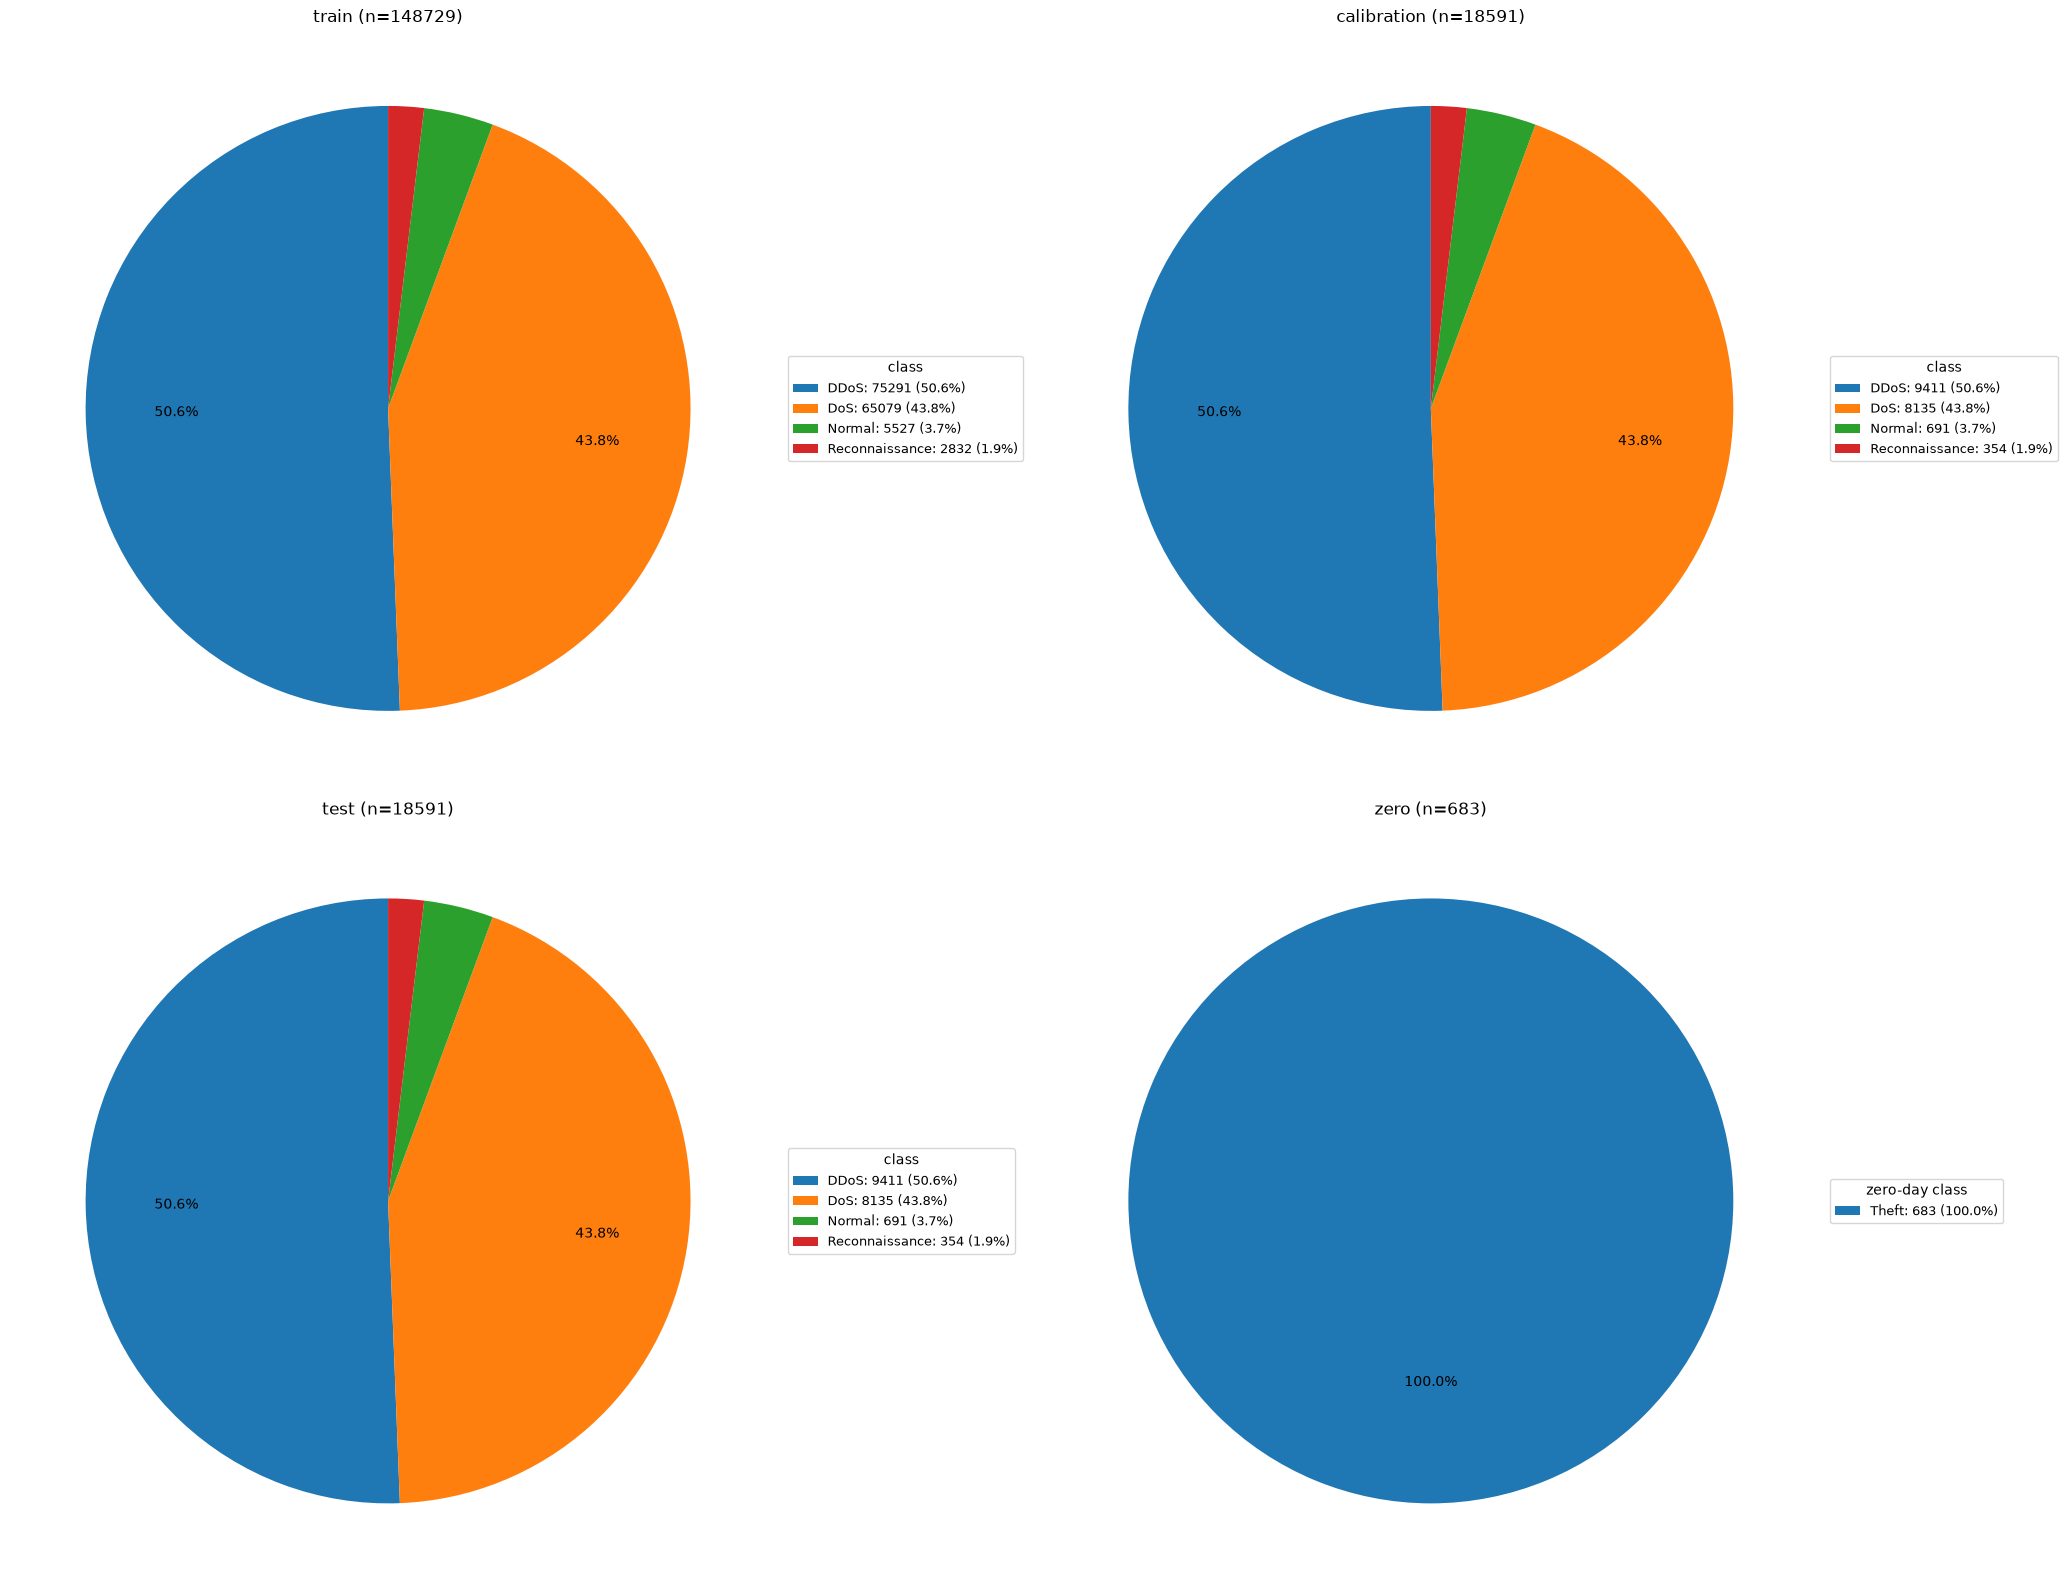

In [7]:
splits = {
    "train": y_train_full,
    "calibration": y_cal_full,
    "test": y_test_full,
}

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.ravel()

# train, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero_full)

vc = df_zero[target_col].value_counts()
ax.pie(
    vc.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
    startangle=90,
)
ax.legend(
    [f"{lab}: {n} ({100 * n / vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero)})")

# remove extra chart if exists
for ax in axes[len(splits) + 1 :]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Data Subset (Optional)

In [8]:
SUBSET = True  # set to False for the full known splits
MORE_SUBSET = False  # set to True for smaller cal/test/zero to make a quick pass
PER_CLASS_CAP = 3000

In [9]:
if SUBSET is True:
    X_train, y_train = capped_sample(
        X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED
    )
else:
    X_train, y_train = X_train_full, y_train_full

if MORE_SUBSET is True:
    X_cal, y_cal = stratified_head(X_cal_full, y_cal_full, 400, seed=SEED)
    X_test, y_test = stratified_head(X_test_full, y_test_full, 400, seed=SEED)
    X_zero, y_zero, idx_zero = stratified_head(
        X_zero_full, y_zero_full, 40, seed=SEED, return_index=True
    )
else:
    X_cal, y_cal = X_cal_full, y_cal_full
    X_test, y_test = X_test_full, y_test_full
    X_zero, y_zero = X_zero_full, y_zero_full
    idx_zero = np.arange(len(X_zero))

df_zero_subset = df_zero.iloc[idx_zero].reset_index(drop=True)

# check shape
print(
    f"train : {X_train.shape, y_train.shape}\n\
cal   : {X_cal.shape, y_cal.shape}\n\
test  : {X_test.shape, y_test.shape}\n\
zero  : {X_zero.shape, y_zero.shape}"
)

train : ((11832, 10), (11832,))
cal   : ((18591, 10), (18591,))
test  : ((18591, 10), (18591,))
zero  : ((683, 10), (683,))


## EDA (After Subset)

number of classes: 4


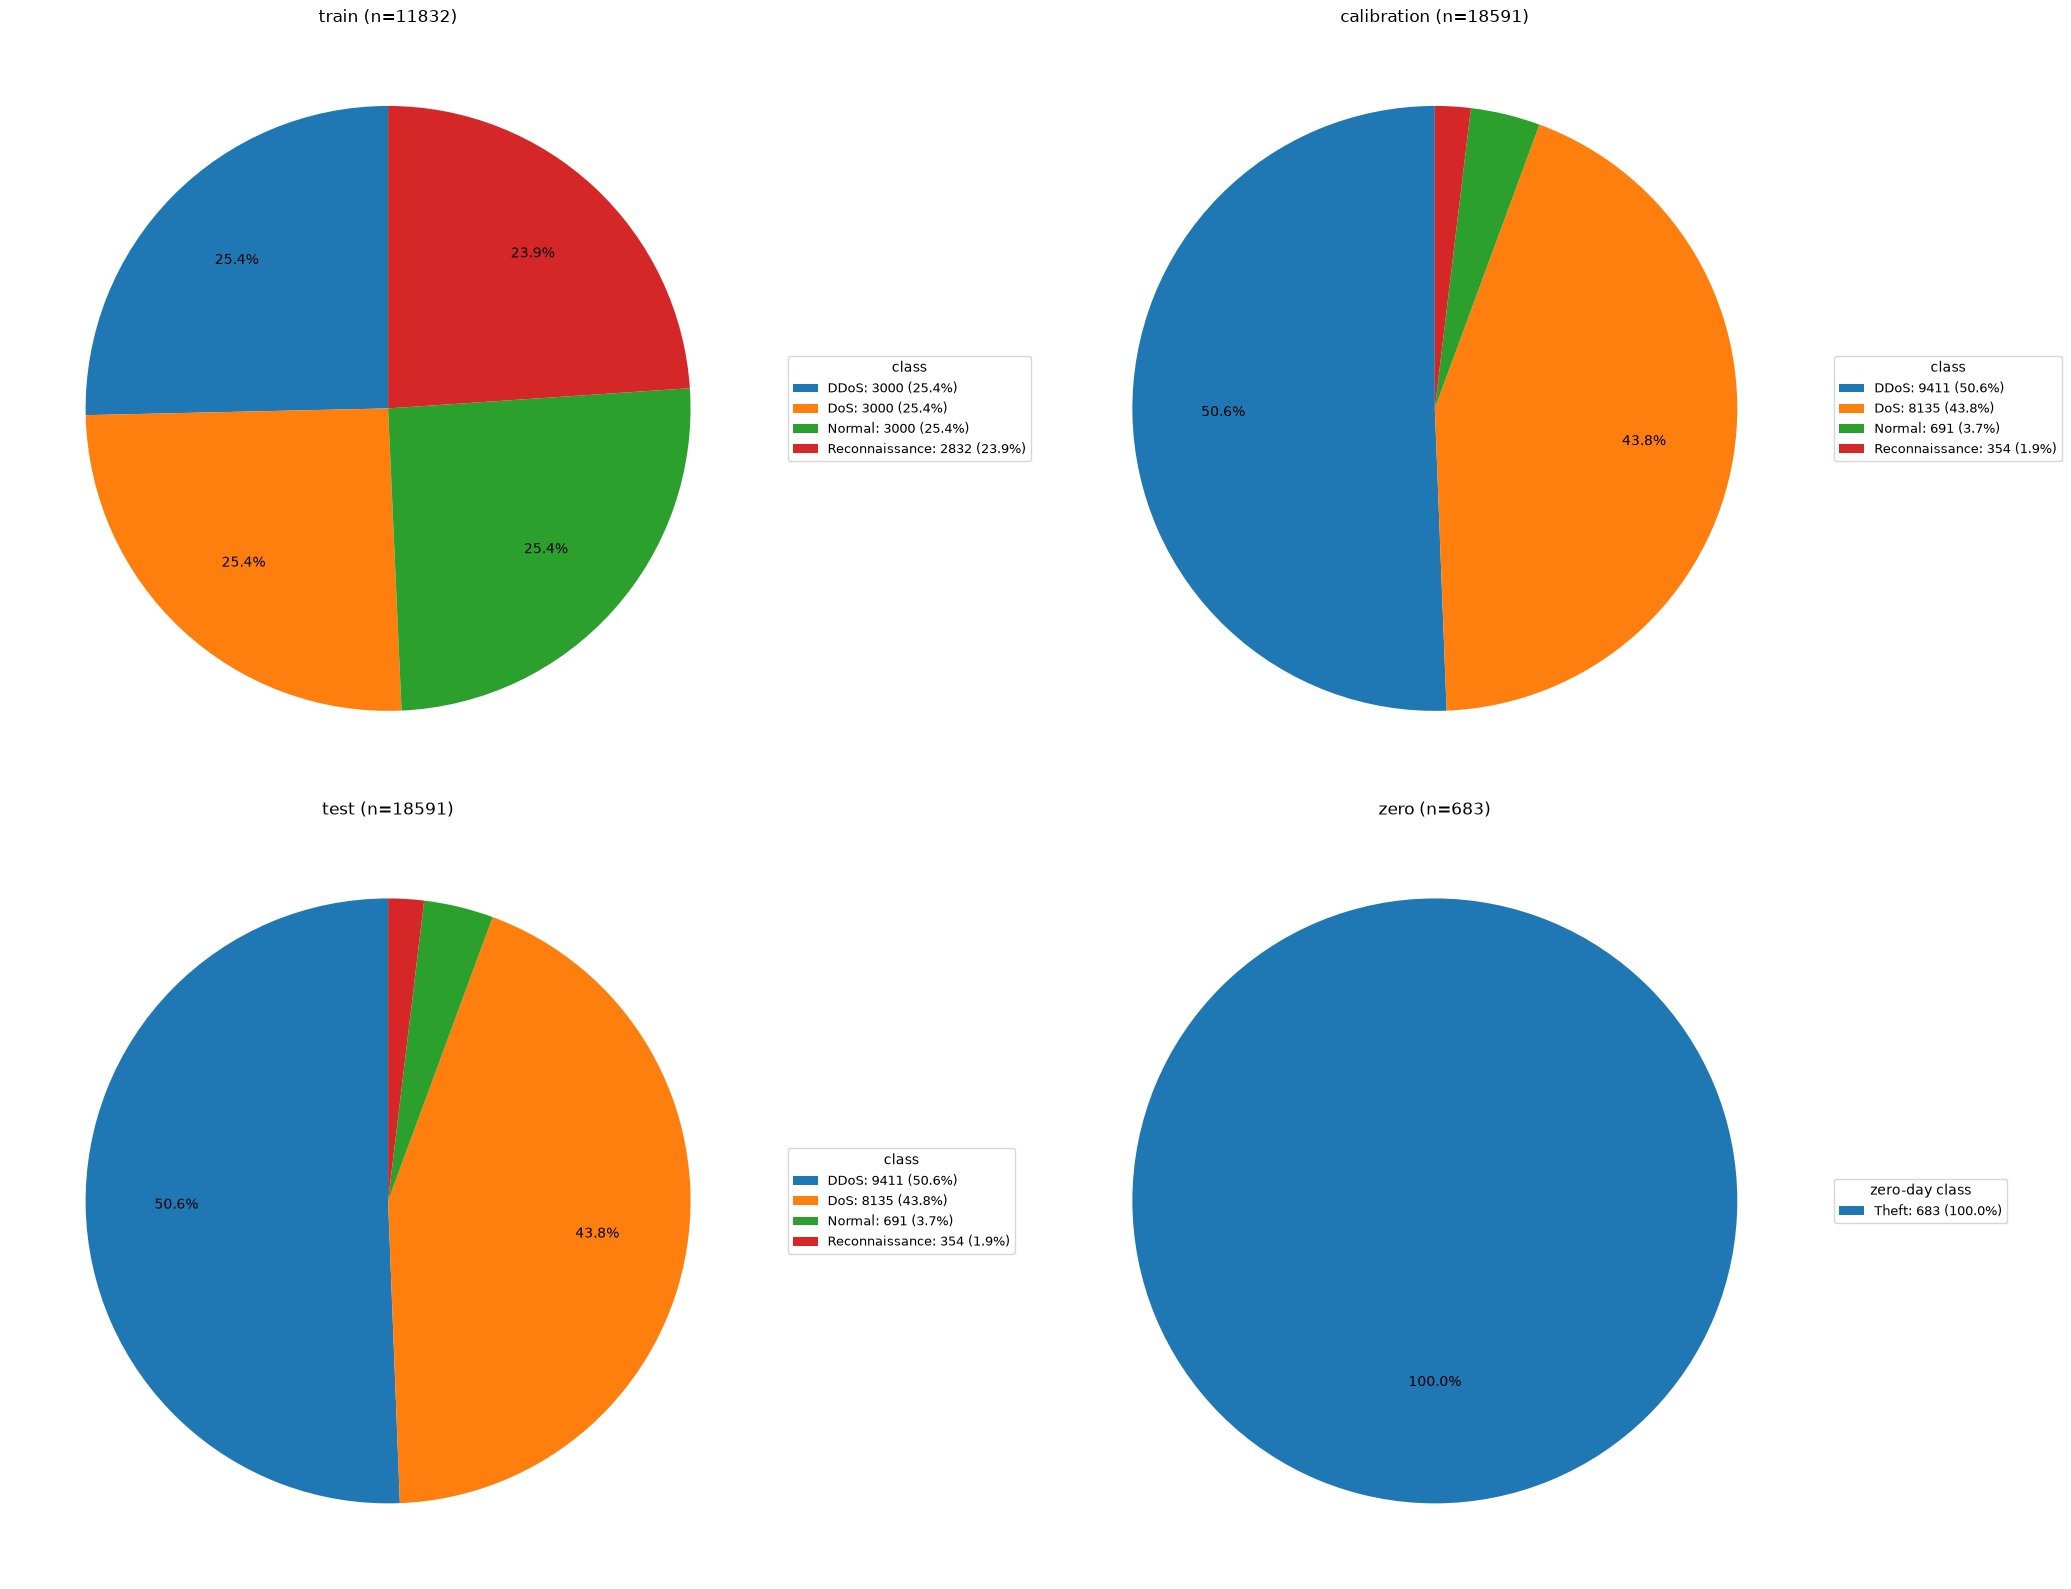

In [10]:
num_classes = len(class_names)
print(f"number of classes: {num_classes}")

splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
}

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.ravel()

for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

ax = axes[len(splits)]
vc = df_zero_subset[target_col].value_counts()
ax.pie(
    vc.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
    startangle=90,
)
ax.legend(
    [f"{lab}: {n} ({100 * n / vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero_subset)})")

for ax in axes[len(splits) + 1 :]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Load Day-23 FROZEN Checkpoint

Reuse $\theta^\star$, prototypes, and the train-fitted scaler / PCA / angle bounds from Day-23.


In [11]:
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY23_NOTEBOOK}-checkpoint.pt",
]

batch_size = DEFAULT_BATCH_SIZE
seed = SEED

In [12]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
history = {}
head = None

if not (LOAD_CHECKPOINT and ckpt_path is not None):
    raise FileNotFoundError(
        f"Day-23 checkpoint not found under {CHECKPOINT_CANDIDATES}. "
        f"Publish it from {DAY23_NOTEBOOK}_(final).ipynb first."
    )

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

theta_star = ckpt["theta"]
if not isinstance(theta_star, torch.nn.Parameter):
    theta_star = torch.nn.Parameter(theta_star)

prototypes = {int(k): v for k, v in ckpt["prototypes"].items()}
class_names = list(ckpt.get("class_names", class_names))
num_classes = int(ckpt.get("num_classes", len(class_names)))
num_qubits = int(ckpt["num_qubits"])
num_layers = int(ckpt.get("num_layers", 2))
noise_rate = float(ckpt.get("noise_rate", DEFAULT_NOISE_RATE))

scaler = ckpt["scaler"]
pca = ckpt.get("pca")
USE_PCA = bool(ckpt.get("use_pca", pca is not None))
x_min = np.asarray(ckpt["angle_x_min"])
x_max = np.asarray(ckpt["angle_x_max"])
angle_max = float(ckpt.get("angle_max", np.pi))
k95 = int(ckpt.get("k95", num_qubits))

if "head_state_dict" in ckpt:
    head = torch.nn.Linear(num_qubits, num_classes)
    head.load_state_dict(ckpt["head_state_dict"])

print(f"loaded checkpoint: {ckpt_path}")
print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")
print(
    f"num_qubits={num_qubits} | num_layers={num_layers} | USE_PCA={USE_PCA} | k95={k95}"
)
print(f"feature_cols: {len(ckpt.get('feature_cols', FEATURE_COLS))}")

loaded checkpoint: artifacts/BoT-IoT/4class-3000each-lr0.01auto-maqt-checkpoint.pt
theta shape: (2, 5, 3) | prototypes: 4
num_qubits=5 | num_layers=2 | USE_PCA=True | k95=5
feature_cols: 10


## Mapping Features $\rightarrow$ [0, $\pi$]


angles cal: (18591, 5), | angles test: (18591, 5), | angles zero: (683, 5) | USE_PCA=True


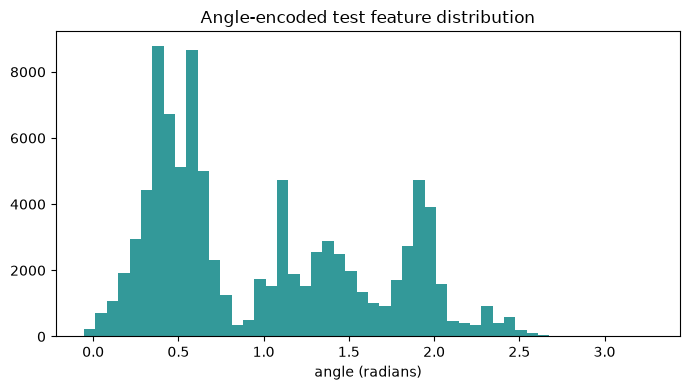

In [13]:
# raw -> scale -> optional pca -> [0, pi] using Day-23 train bounds
pca_for_angles = pca if USE_PCA else None
X_cal_angles = to_angles(
    X_cal, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)
X_test_angles = to_angles(
    X_test, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)
X_zero_angles = to_angles(
    X_zero, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)
X_train_angles = to_angles(
    X_train, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)

print(
    f"angles cal: {X_cal_angles.shape}, | angles test: {X_test_angles.shape}, | angles zero: {X_zero_angles.shape} | USE_PCA={USE_PCA}"
)

fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))
ax1.hist(X_test_angles.flatten(), bins=50, color="teal", alpha=0.8)
ax1.set_xlabel("angle (radians)")
ax1.set_title("Angle-encoded test feature distribution")
plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$$
x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)
$$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [14]:
print(
    f"num_qubits={num_qubits} (from Day-23) | num_layers={num_layers} | noise_rate={noise_rate}"
)

num_qubits=5 (from Day-23) | num_layers=2 | noise_rate=0.01


In [15]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(
    num_qubits
)  # or qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(
    dev, num_qubits, num_layers, noise_rate=noise_rate
)

# move model tensors to device
theta_star = theta_star.to(device)
if not isinstance(theta_star, torch.nn.Parameter):
    theta_star = torch.nn.Parameter(theta_star)
prototypes = {int(k): v.to(device) for k, v in prototypes.items()}
if head is not None:
    head = head.to(device)

print(f"device={device}")

device=cuda


## Forward Cache

- Run the encoder once per split
- Store $(z, \rho)$ on CPU
- Downstream conformal / Algo-3 reuse these without re-running the circuit

In [16]:
cache = ForwardCache(store_device="cpu")

CACHE_SPLITS = {
    "train": X_train_angles,
    "cal": X_cal_angles,
    "test": X_test_angles,
    "zeroday": X_zero_angles,
}

t0 = time.time()
for key, X_ang in CACHE_SPLITS.items():
    entry = cache.compute(
        key,
        X_ang,
        theta_star,
        forward_circuit,
        device=device,
        batch_size=batch_size,
        p=noise_rate,
    )
    print(
        f"[{key:8s}] n={entry['n']:,}  rho={tuple(entry['rho'].shape)}  z={tuple(entry['z'].shape)}"
    )
print(f"forward cache built in {time.time() - t0:.1f}s")

# optional disk persist (reload skips recompute if you load below instead)
cache_dir = Path("caches") / dataset
cache_dir.mkdir(parents=True, exist_ok=True)
cache_path = cache_dir / f"{NOTEBOOK_NAME}-forward_cache.pt"
save_dict = {
    "notebook": NOTEBOOK_NAME,
    "checkpoint": str(ckpt_path) if ckpt_path else None,
    "day23_notebook": DAY23_NOTEBOOK,
    "num_qubits": num_qubits,
    "num_layers": num_layers,
    "noise_rate": noise_rate,
    "class_names": list(class_names),
    "seed": SEED,
}
for key in CACHE_SPLITS:
    entry = cache.get(key)
    save_dict[f"{key}_z"] = entry["z"]
    save_dict[f"{key}_rho"] = entry["rho"]
    save_dict[f"{key}_n"] = entry["n"]
torch.save(save_dict, cache_path)
print(f"saved cache: {cache_path.resolve()} ({cache_path.stat().st_size / 1e6:.1f} MB)")

[train   ] n=11,832  rho=(11832, 32, 32)  z=(11832, 5)
[cal     ] n=18,591  rho=(18591, 32, 32)  z=(18591, 5)
[test    ] n=18,591  rho=(18591, 32, 32)  z=(18591, 5)
[zeroday ] n=683  rho=(683, 32, 32)  z=(683, 5)
forward cache built in 37.9s
saved cache: /home/lawun330/Desktop/quantum-sentinel/caches/BoT-IoT/4class-3000each-lr0.01auto-algo3-cached-forward_cache.pt (815.2 MB)


## Lipschitz Bound $L_\varphi$ (Analytic R/2)

**Lemma 1**: For angle encoding with data reupload, $L_\varphi = R/2$ with $R=$ `num_layers`.

In [17]:
L_phi = analytic_lipschitz_bound(num_layers, reupload=True)
lphi_path = None
print(f"using analytic L_phi=R/2={L_phi:.4f} (num_layers={num_layers})")

using analytic L_phi=R/2=1.0000 (num_layers=2)


## Conformal Zero-Day Threshold Calibration (q)

- Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.
- Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

Recalibrate $q$ on Day-23 angle-encoded $X_{\mathrm{cal}}$.

In [18]:
alpha = DEFAULT_ALPHA
alpha

0.05

In [19]:
cal_scores = cached_nonconformity_scores(
    cache.get("cal"),
    prototypes,
    device=device,
    batch_size=batch_size,
)
q, scores_sorted = threshold_from_scores(cal_scores, alpha=alpha)
q_source = "threshold_from_scores(cal_scores) on Day-23 checkpoint + ForwardCache"
print(f"calibrated q={q:.6f} (alpha={alpha}, n_cal={len(cal_scores)})")

calibrated q=0.292728 (alpha=0.05, n_cal=18591)


### Note
α-sweep and per-class FAR run **after** Global infer, reusing `cal_scores` + `scores_test_g` (see the diagnostics cell below Global vs Mondrian).

In [20]:
Cf = DEFAULT_CF
zero_day = ZERO_DAY
p = noise_rate
label_ids = list(range(num_classes))
y_test_np = to_np_y(y_test).astype(int)

print(f"p       : {p}")
print(f"L_phi   : {L_phi:.4f}")
print(f"C_f     : {Cf}")
print(f"q       : {q:.6f}")

p       : 0.01
L_phi   : 1.0000
C_f     : 1.0
q       : 0.292728


## Global vs Mondrian (Class-conditional) Conformal

Run **once** on the ForwardCache, then reuse for RQ1 / test reports.

- **Global**: one threshold $q$ (already calibrated).
- **Mondrian**: per-class thresholds $q_c$ (reuses `cal_scores`).

In [21]:
# Mondrian calibration (per-class q_c); reuse cal_scores from global calibrate
q_by_class, calib_meta = cached_class_conditional_calibrate(
    cache.get("cal"),
    y_cal,
    prototypes,
    alpha=alpha,
    device=device,
    batch_size=batch_size,
    fallback="global",
    scores=cal_scores,
)

print("Per-class (Mondrian) thresholds:")
for c in sorted(prototypes.keys()):
    m = calib_meta[c]
    print(f"  {class_names[c]:15s} n={m['n']:5d}  q={m['q']:.4f}  status={m['status']}")
print(
    f"  global (marginal) q = {calib_meta['_global']['q']:.4f}  |  notebook global q = {q:.4f}"
)

Per-class (Mondrian) thresholds:
  DDoS            n= 9411  q=0.2966  status=ok
  DoS             n= 8135  q=0.2579  status=ok
  Normal          n=  691  q=0.4765  status=ok
  Reconnaissance  n=  354  q=0.2562  status=ok
  global (marginal) q = 0.2927  |  notebook global q = 0.2927


In [22]:
print("=" * 60)
print("ZERO-DAY DETECTION: GLOBAL vs MONDRIAN")
print("=" * 60)

# --- Global ---
labels_zday_g, radii_zday_g, scores_zday_g, _ = cached_qsnet_infer(
    cache.get("zeroday"),
    prototypes,
    q,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)
labels_test_g, radii_test_g, scores_test_g, f_maps_test_g = cached_qsnet_infer(
    cache.get("test"),
    prototypes,
    q,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)

tp_g, n_g = int(np.sum(labels_zday_g == ZERO_DAY)), len(labels_zday_g)
fp_g, m_g = int(np.sum(labels_test_g == ZERO_DAY)), len(labels_test_g)
TPR_g, FPR_g = tp_g / n_g, fp_g / m_g
tpr_g_lo, tpr_g_hi = clopper_pearson_ci(tp_g, n_g)
fpr_g_lo, fpr_g_hi = clopper_pearson_ci(fp_g, m_g)

accepted_g = labels_test_g != ZERO_DAY
class_acc_g = (
    float(np.mean(labels_test_g[accepted_g] == y_test_np[accepted_g]))
    if accepted_g.any()
    else float("nan")
)

# --- Mondrian ---
labels_zday_pc, radii_zday_pc, scores_zday_pc, _ = cached_qsnet_infer_per_class(
    cache.get("zeroday"),
    prototypes,
    q_by_class,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)
labels_test_pc, radii_test_pc, scores_test_pc, _ = cached_qsnet_infer_per_class(
    cache.get("test"),
    prototypes,
    q_by_class,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)

tp_pc, n_pc = int(np.sum(labels_zday_pc == ZERO_DAY)), len(labels_zday_pc)
fp_pc, m_pc = int(np.sum(labels_test_pc == ZERO_DAY)), len(labels_test_pc)
TPR_pc, FPR_pc = tp_pc / n_pc, fp_pc / m_pc
tpr_pc_lo, tpr_pc_hi = clopper_pearson_ci(tp_pc, n_pc)
fpr_pc_lo, fpr_pc_hi = clopper_pearson_ci(fp_pc, m_pc)

accepted_pc = labels_test_pc != ZERO_DAY
class_acc_pc = (
    float(np.mean(labels_test_pc[accepted_pc] == y_test_np[accepted_pc]))
    if accepted_pc.any()
    else float("nan")
)

df_global_vs_mondrian = pd.DataFrame(
    [
        {
            "method": "Global",
            "TPR": TPR_g,
            "TPR_lo": tpr_g_lo,
            "TPR_hi": tpr_g_hi,
            "FPR": FPR_g,
            "FPR_lo": fpr_g_lo,
            "FPR_hi": fpr_g_hi,
            "class_acc_accepted": class_acc_g,
        },
        {
            "method": "Mondrian",
            "TPR": TPR_pc,
            "TPR_lo": tpr_pc_lo,
            "TPR_hi": tpr_pc_hi,
            "FPR": FPR_pc,
            "FPR_lo": fpr_pc_lo,
            "FPR_hi": fpr_pc_hi,
            "class_acc_accepted": class_acc_pc,
        },
    ]
)

print(
    f"[global]   TPR={TPR_g:.4f} (CI [{tpr_g_lo:.4f},{tpr_g_hi:.4f}])  "
    f"FPR={FPR_g:.4f} (CI [{fpr_g_lo:.4f},{fpr_g_hi:.4f}])  "
    f"known-acc(accepted)={class_acc_g:.4f}"
)
print(
    f"[mondrian] TPR={TPR_pc:.4f} (CI [{tpr_pc_lo:.4f},{tpr_pc_hi:.4f}])  "
    f"FPR={FPR_pc:.4f} (CI [{fpr_pc_lo:.4f},{fpr_pc_hi:.4f}])  "
    f"known-acc(accepted)={class_acc_pc:.4f}"
)

# reuse global branch for downstream test reports / hist / RQ1 (no second infer)
y_pred, radii, novelty_scores, f_maps = (
    labels_test_g,
    radii_test_g,
    scores_test_g,
    f_maps_test_g,
)
y_zero_pred, radii_zero, scores_zero = labels_zday_g, radii_zday_g, scores_zday_g
detection_rate = float(TPR_g)

df_global_vs_mondrian

ZERO-DAY DETECTION: GLOBAL vs MONDRIAN
[global]   TPR=0.2387 (CI [0.2071,0.2724])  FPR=0.0471 (CI [0.0441,0.0502])  known-acc(accepted)=0.5208
[mondrian] TPR=0.2899 (CI [0.2561,0.3255])  FPR=0.0367 (CI [0.0341,0.0395])  known-acc(accepted)=0.5260


,method,TPR,TPR_lo,TPR_hi,FPR,FPR_lo,FPR_hi,class_acc_accepted
0,Global,0.238653,0.207140,0.272443,0.047066,0.044066,0.050209,0.520772
1,Mondrian,0.289898,0.256109,0.325513,0.036738,0.034080,0.039543,0.525966


In [23]:
# diagnostics from already-computed scores (no extra fidelity / nonconformity pass)
# cal_scores    -> from global calibrate
# scores_test_g -> from Global infer above (same for Mondrian)

alphas = (0.01, 0.05, 0.1, 0.2)
alpha_rows = conformal_alpha_sweep_from_scores(cal_scores, scores_test_g, alphas=alphas)
df_alpha = pd.DataFrame(alpha_rows)
print("alpha sweep (from cal_scores + scores_test_g):")
print(df_alpha.to_string(index=False))
print()

q_global_map = {c: float(q) for c in prototypes}
far_global = cached_per_class_far(
    cache.get("test"),
    y_test,
    prototypes,
    q_global_map,
    device=device,
    batch_size=batch_size,
    scores=scores_test_g,
)
far_mondrian = cached_per_class_far(
    cache.get("test"),
    y_test,
    prototypes,
    q_by_class,
    device=device,
    batch_size=batch_size,
    scores=scores_test_g,
)

df_far = pd.DataFrame(
    [
        {
            "class": class_names[r["class"]],
            "n": r["n"],
            "FAR_global": r["empirical_far"],
            "FAR_mondrian": r2["empirical_far"],
            "q_global": r["q"],
            "q_mondrian": r2["q"],
        }
        for r, r2 in zip(far_global, far_mondrian)
    ]
)
df_far["abs_dev_global"] = (df_far["FAR_global"] - alpha).abs()
df_far["abs_dev_mondrian"] = (df_far["FAR_mondrian"] - alpha).abs()
print(
    f"FAR spread  global={df_far['FAR_global'].max() - df_far['FAR_global'].min():.4f}  "
    f"mondrian={df_far['FAR_mondrian'].max() - df_far['FAR_mondrian'].min():.4f}"
)
df_far

alpha sweep (from cal_scores + scores_test_g):
 alpha        q  empirical_false_alarm_rate  min_calibration_size  n_cal
  0.01 0.402463                    0.009467                  99.0  18591
  0.05 0.292728                    0.047066                  19.0  18591
  0.10 0.251516                    0.094992                   9.0  18591
  0.20 0.179801                    0.199021                   4.0  18591

FAR spread  global=0.3004  mondrian=0.0228


,class,n,FAR_global,FAR_mondrian,q_global,q_mondrian,abs_dev_global,abs_dev_mondrian
0,DDoS,9411,0.057061,0.050685,0.292728,0.296626,0.007061,0.000685
1,DoS,8135,0.013645,0.043270,0.292728,0.257922,0.036355,0.006730
2,Normal,691,0.314038,0.065123,0.292728,0.476454,0.264038,0.015123
3,Reconnaissance,354,0.028249,0.042373,0.292728,0.256198,0.021751,0.007627


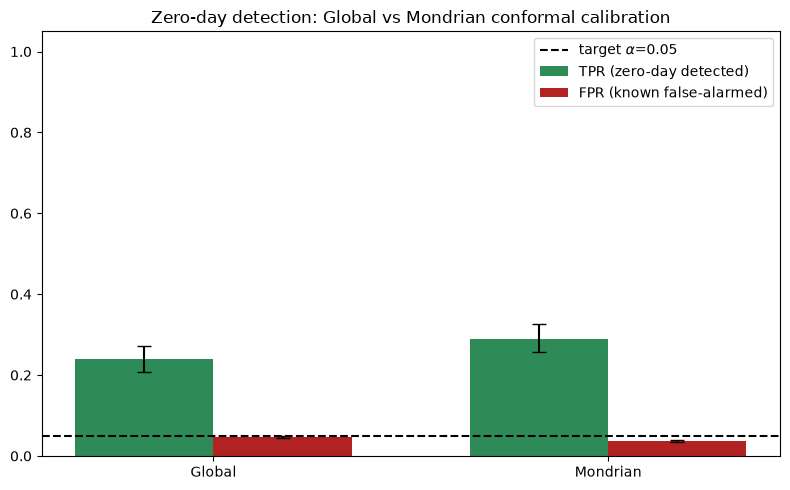

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_global_vs_mondrian))
width = 0.35
tpr_err = [
    df_global_vs_mondrian["TPR"] - df_global_vs_mondrian["TPR_lo"],
    df_global_vs_mondrian["TPR_hi"] - df_global_vs_mondrian["TPR"],
]
fpr_err = [
    df_global_vs_mondrian["FPR"] - df_global_vs_mondrian["FPR_lo"],
    df_global_vs_mondrian["FPR_hi"] - df_global_vs_mondrian["FPR"],
]
ax.bar(
    x - width / 2,
    df_global_vs_mondrian["TPR"],
    width,
    yerr=tpr_err,
    capsize=5,
    label="TPR (zero-day detected)",
    color="seagreen",
)
ax.bar(
    x + width / 2,
    df_global_vs_mondrian["FPR"],
    width,
    yerr=fpr_err,
    capsize=5,
    label="FPR (known false-alarmed)",
    color="firebrick",
)
ax.axhline(alpha, color="black", linestyle="--", label=rf"target $\alpha$={alpha}")
ax.set_xticks(x)
ax.set_xticklabels(df_global_vs_mondrian["method"])
ax.set_ylim(0, 1.05)
ax.set_title("Zero-day detection: Global vs Mondrian conformal calibration")
ax.legend()
plt.tight_layout()
plt.show()

## Score Histograms: Global vs Mondrian q

Same nonconformity scores $s(x)=1-F_{\max}$

- Global uses one $q$
- Mondrian uses per-class $q_c$.

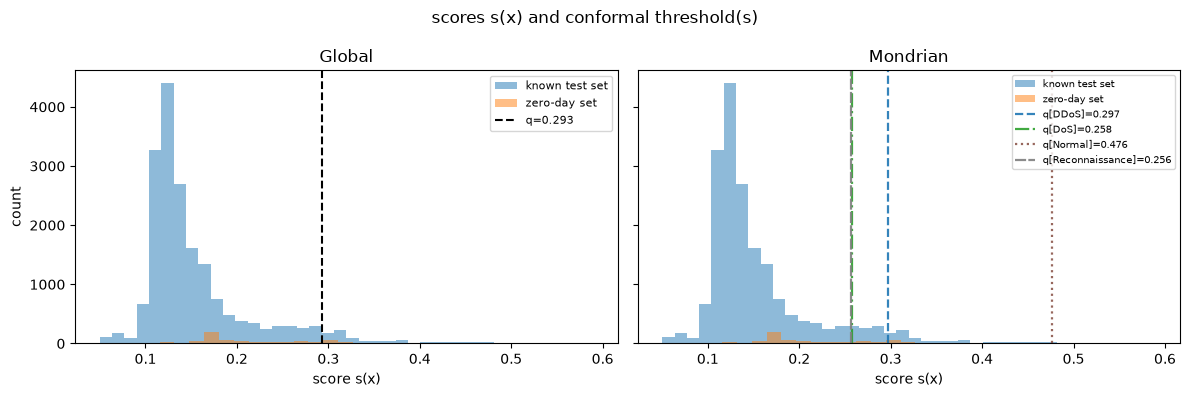

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# --- Global: one q ---
axes[0].hist(scores_test_g, bins=40, alpha=0.5, label="known test set")
axes[0].hist(scores_zday_g, bins=30, alpha=0.5, label="zero-day set")
axes[0].axvline(q, color="k", linestyle="--", label=f"q={q:.3f}")
axes[0].set_title("Global")
axes[0].set_xlabel("score s(x)")
axes[0].set_ylabel("count")
axes[0].legend(fontsize=8)

# --- Mondrian: same scores, per-class q_c ---
axes[1].hist(scores_test_pc, bins=40, alpha=0.5, label="known test set")
axes[1].hist(scores_zday_pc, bins=30, alpha=0.5, label="zero-day set")
_dash_styles = ["--", "-.", ":", (0, (5, 1)), (0, (3, 1, 1, 1)), (0, (1, 1))]
_q_items = sorted(q_by_class.items())
_colors = plt.cm.tab10(np.linspace(0, 1, max(len(_q_items), 1), endpoint=False))
for i, (c, q_c) in enumerate(_q_items):
    axes[1].axvline(
        q_c,
        color=_colors[i],
        linestyle=_dash_styles[i % len(_dash_styles)],
        linewidth=1.6,
        alpha=0.9,
        label=f"q[{class_names[c]}]={q_c:.3f}",
    )
axes[1].set_title("Mondrian")
axes[1].set_xlabel("score s(x)")
axes[1].legend(fontsize=7)

fig.suptitle("scores s(x) and conformal threshold(s)")
plt.tight_layout()
plt.show()

## RQ1 Detection Numbers

Flip `CHOSEN_STRATEGY` to promote Global or Mondrian as the primary RQ1 numbers.

In [26]:
# which conformal strategy is primary for RQ1 / downstream Global-style reports
CHOSEN_STRATEGY = "global"  # "global" | "mondrian"

strategies = {
    "global": {
        "chosen_as_strategy": CHOSEN_STRATEGY == "global",
        "q": float(q),
        "TPR_zeroday": float(TPR_g),
        "FPR_known": float(FPR_g),
        "class_acc_known": float(class_acc_g),
        "TPR_lo": float(tpr_g_lo),
        "TPR_hi": float(tpr_g_hi),
        "FPR_lo": float(fpr_g_lo),
        "FPR_hi": float(fpr_g_hi),
    },
    "mondrian": {
        "chosen_as_strategy": CHOSEN_STRATEGY == "mondrian",
        "q_by_class": {int(k): float(v) for k, v in q_by_class.items()},
        "TPR_zeroday": float(TPR_pc),
        "FPR_known": float(FPR_pc),
        "class_acc_known": float(class_acc_pc),
        "TPR_lo": float(tpr_pc_lo),
        "TPR_hi": float(tpr_pc_hi),
        "FPR_lo": float(fpr_pc_lo),
        "FPR_hi": float(fpr_pc_hi),
    },
}

# primary RQ1 aliases (charts / prints use these)
_primary = strategies[CHOSEN_STRATEGY]
TPR_zeroday = float(_primary["TPR_zeroday"])
FPR_known = float(_primary["FPR_known"])
class_acc_known = float(_primary["class_acc_known"])

# side-by-side convenience names (always both strategies)
TPR_zeroday_global = float(strategies["global"]["TPR_zeroday"])
FPR_known_global = float(strategies["global"]["FPR_known"])
class_acc_known_global = float(strategies["global"]["class_acc_known"])
TPR_zeroday_mondrian = float(strategies["mondrian"]["TPR_zeroday"])
FPR_known_mondrian = float(strategies["mondrian"]["FPR_known"])
class_acc_known_mondrian = float(strategies["mondrian"]["class_acc_known"])

print(f"target alpha={alpha}")
print(f"chosen_strategy={CHOSEN_STRATEGY}")
print()
for name, m in strategies.items():
    tag = " [CHOSEN]" if m["chosen_as_strategy"] else ""
    print(f"=== {name}{tag} ===")
    print(f"  TPR_zeroday:      {m['TPR_zeroday']:.4f}")
    print(f"  FPR_known:        {m['FPR_known']:.4f}")
    print(f"  class_acc_known:  {m['class_acc_known']:.4f}")
print()
print(f"n_test={len(y_test_np)} | n_zeroday={len(X_zero_angles)}")

target alpha=0.05
chosen_strategy=global

=== global [CHOSEN] ===
  TPR_zeroday:      0.2387
  FPR_known:        0.0471
  class_acc_known:  0.5208
=== mondrian ===
  TPR_zeroday:      0.2899
  FPR_known:        0.0367
  class_acc_known:  0.5260

n_test=18591 | n_zeroday=683


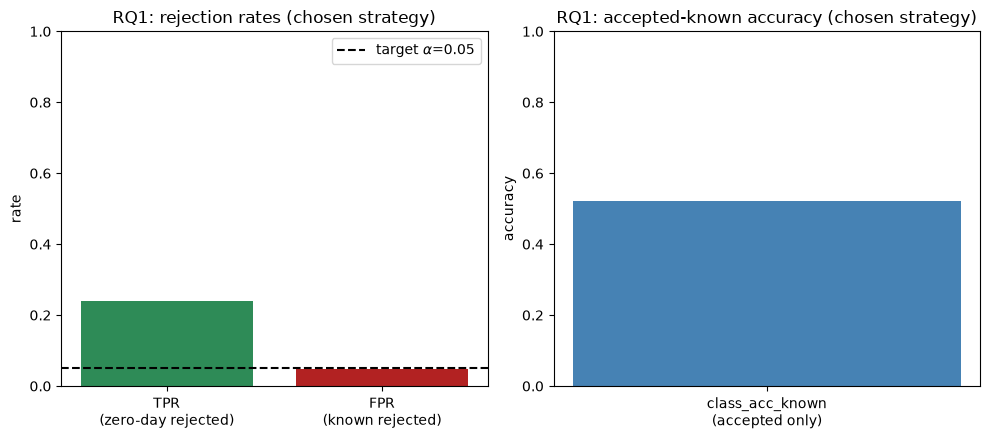

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].bar(
    ["TPR\n(zero-day rejected)", "FPR\n(known rejected)"],
    [TPR_zeroday, FPR_known],
    color=["seagreen", "firebrick"],
)
axes[0].axhline(alpha, color="black", linestyle="--", label=rf"target $\alpha$={alpha}")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("rate")
axes[0].set_title("RQ1: rejection rates (chosen strategy)")
axes[0].legend()

axes[1].bar(["class_acc_known\n(accepted only)"], [class_acc_known], color="steelblue")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("accuracy")
axes[1].set_title("RQ1: accepted-known accuracy (chosen strategy)")

plt.tight_layout()
plt.show()

## Evaluation on Training Samples Themselves (Non-Rejected By $q$)

In [28]:
y_pred_train, radii_train, novelty_scores_train, f_maps_train = cached_qsnet_infer(
    cache.get("train"),
    prototypes,
    q,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)
y_train_np = to_np_y(y_train).astype(int)
label_ids = list(range(num_classes))

[train] mean certified radius (accepted): 0.0364
[train] reject rate (known): 0.1115 | acc (accepted): 0.5758

[train] classification report (accepted only):
                precision    recall  f1-score   support

          DDoS       0.56      0.24      0.34      2808
           DoS       0.43      0.82      0.57      2948
        Normal       1.00      0.17      0.30      2022
Reconnaissance       0.77      0.96      0.85      2735

      accuracy                           0.58     10513
     macro avg       0.69      0.55      0.51     10513
  weighted avg       0.66      0.58      0.53     10513



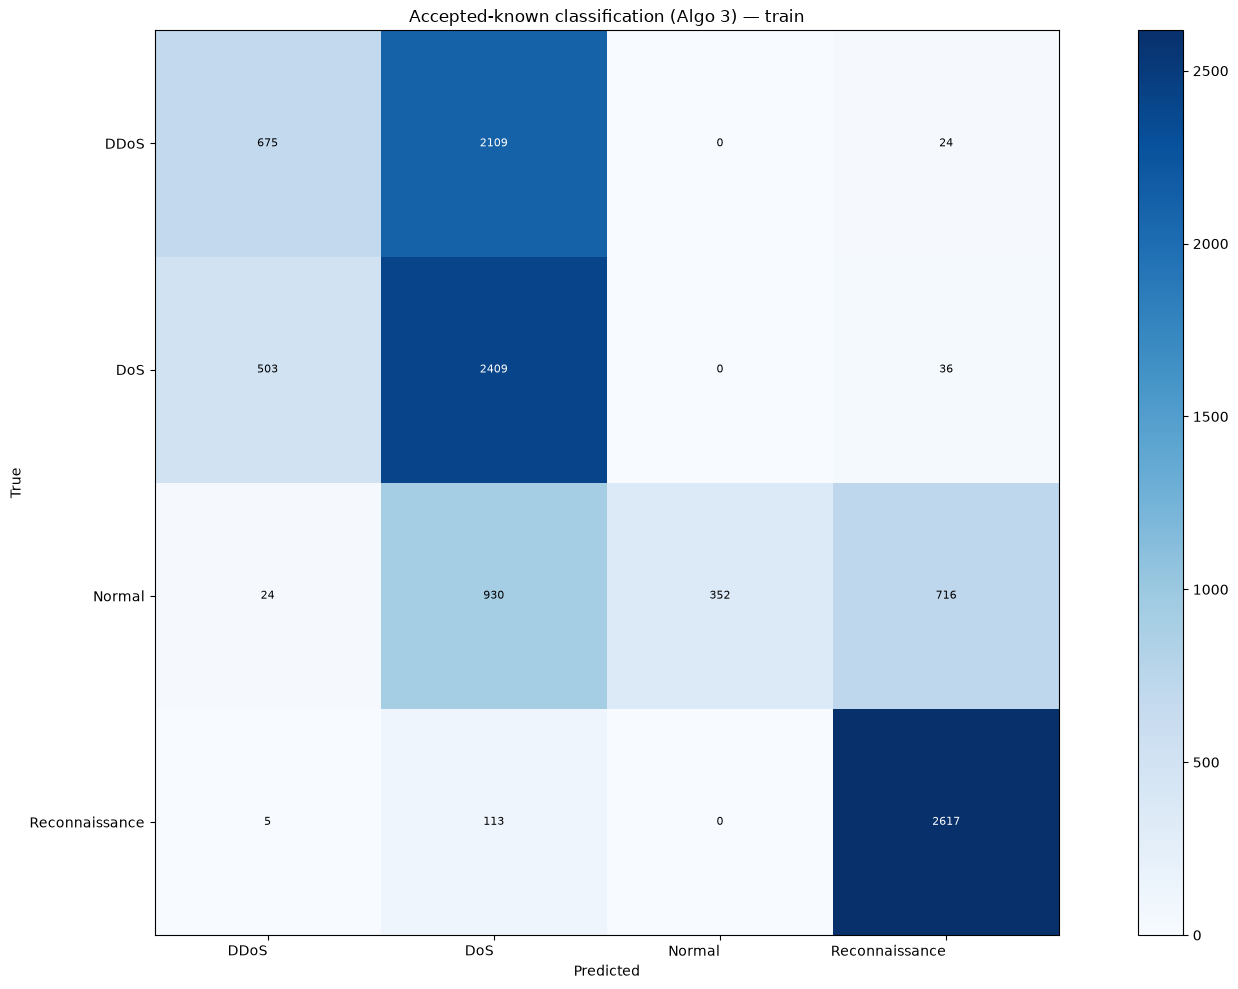

In [29]:
known_mask_train = y_pred_train != ZERO_DAY
train_eval_rej_rate = float(1.0 - known_mask_train.mean())
train_eval_acc = (
    float(np.mean(y_pred_train[known_mask_train] == y_train_np[known_mask_train]))
    if known_mask_train.any()
    else 0.0
)
train_eval_macro_f1 = float(
    f1_score(
        y_train_np[known_mask_train],
        y_pred_train[known_mask_train],
        average="macro",
        labels=label_ids,
        zero_division=0,
    )
)
train_eval_radius_mean = (
    float(radii_train[known_mask_train].mean())
    if known_mask_train.any()
    else float("nan")
)

print(f"[train] mean certified radius (accepted): {train_eval_radius_mean:.4f}")
print(
    f"[train] reject rate (known): {train_eval_rej_rate:.4f} | acc (accepted): {train_eval_acc:.4f}"
)

if known_mask_train.any():
    print("\n[train] classification report (accepted only):")
    print(
        classification_report(
            y_train_np[known_mask_train],
            y_pred_train[known_mask_train],
            labels=label_ids,
            target_names=class_names,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_train_np[known_mask_train],
        y_pred_train[known_mask_train],
        labels=label_ids,
    )

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3) — train",
    )
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Test Samples (Non-Rejected By $q$)

[test] mean certified radius (accepted): 0.0120
[test] reject rate (known): 0.0471 | acc (accepted): 0.5208

[test] classification report (accepted only):
                precision    recall  f1-score   support

          DDoS       0.62      0.25      0.36      8874
           DoS       0.49      0.82      0.61      8024
        Normal       1.00      0.16      0.27       474
Reconnaissance       0.52      0.95      0.67       344

      accuracy                           0.52     17716
     macro avg       0.66      0.55      0.48     17716
  weighted avg       0.57      0.52      0.48     17716



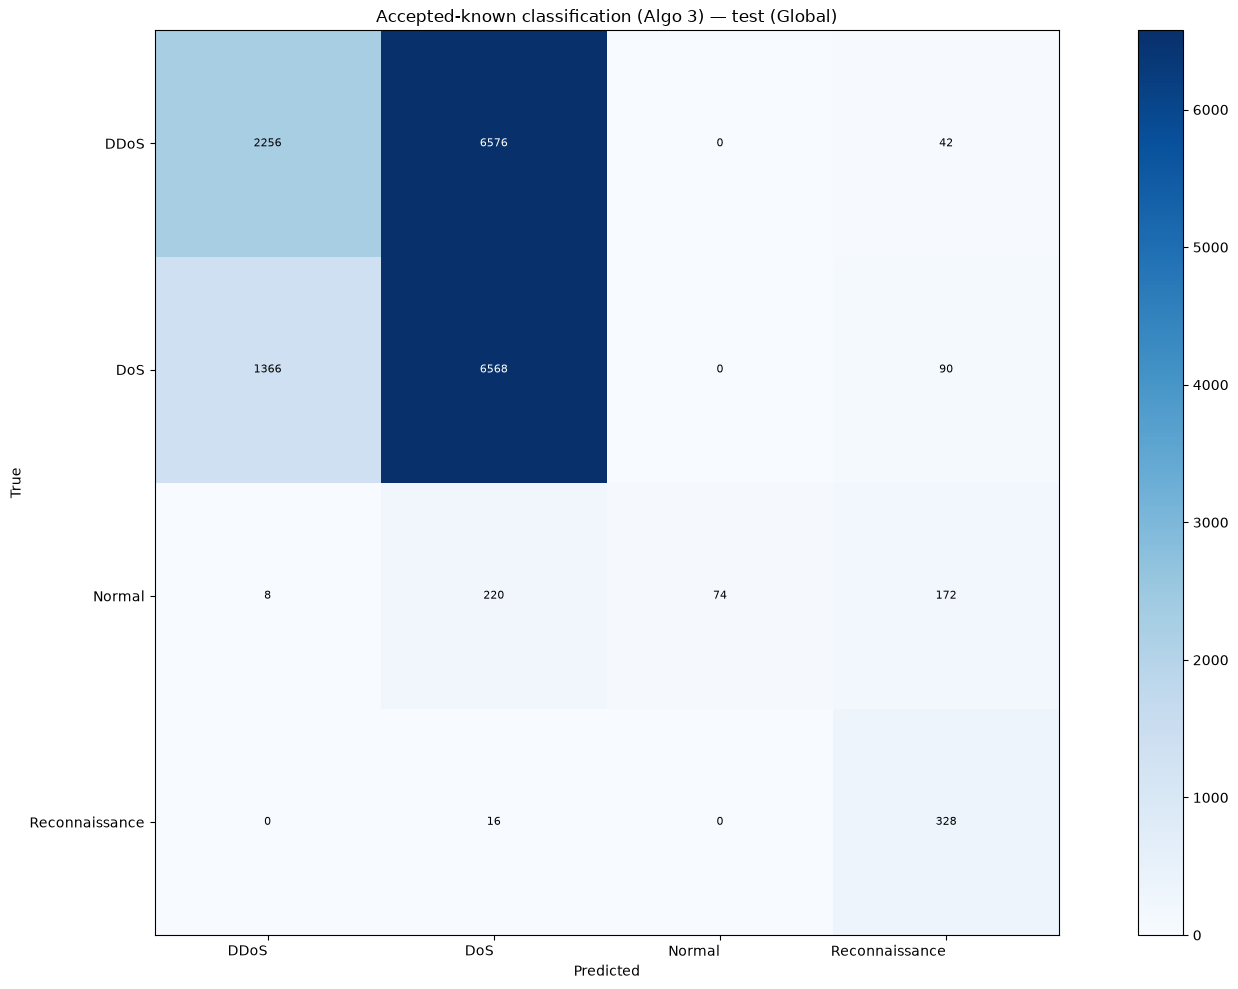

In [30]:
# Global test branch (must not be overwritten by train eval)
y_pred, radii, novelty_scores, f_maps = (
    labels_test_g,
    radii_test_g,
    scores_test_g,
    f_maps_test_g,
)
known_mask_test = y_pred != ZERO_DAY
test_eval_rej_rate = float(1.0 - known_mask_test.mean())
test_eval_acc = (
    float(np.mean(y_pred[known_mask_test] == y_test_np[known_mask_test]))
    if known_mask_test.any()
    else 0.0
)
test_eval_macro_f1 = float(
    f1_score(
        y_test_np[known_mask_test],
        y_pred[known_mask_test],
        average="macro",
        labels=label_ids,
        zero_division=0,
    )
)
test_eval_radius_mean = (
    float(radii[known_mask_test].mean()) if known_mask_test.any() else float("nan")
)

print(f"[test] mean certified radius (accepted): {test_eval_radius_mean:.4f}")
print(
    f"[test] reject rate (known): {test_eval_rej_rate:.4f} | acc (accepted): {test_eval_acc:.4f}"
)
assert abs(test_eval_rej_rate - FPR_g) < 1e-12

if known_mask_test.any():
    print("\n[test] classification report (accepted only):")
    print(
        classification_report(
            y_test_np[known_mask_test],
            y_pred[known_mask_test],
            labels=label_ids,
            target_names=class_names,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_test_np[known_mask_test], y_pred[known_mask_test], labels=label_ids
    )

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3) — test (Global)",
    )
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Class-Balanced Test Samples (Non-Rejected By $q$)


Running representative DPP coreset sampling (cap=350)...
Coreset selected: 1400 samples (from full test n=18591).


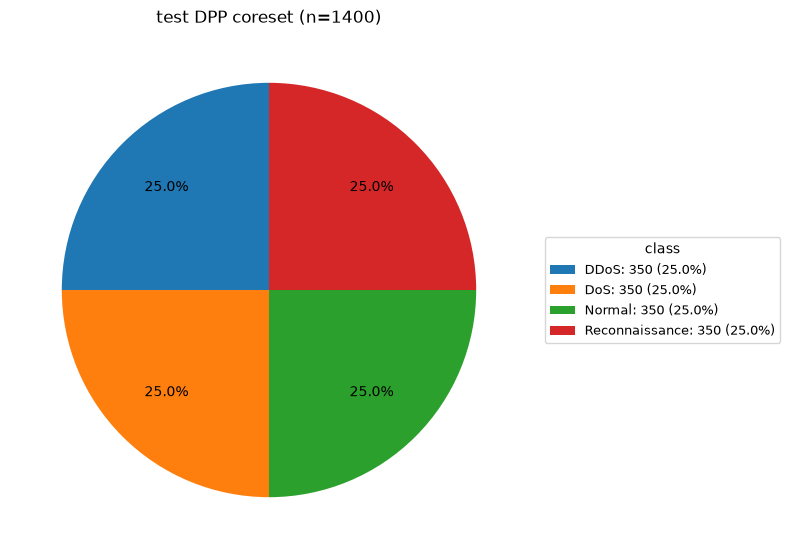

In [31]:
from scripts.data import greedy_dpp_sample

VAL_PER_CAP = 350
print(f"\nRunning representative DPP coreset sampling (cap={VAL_PER_CAP})...")

# coreset from FULL test pool (may differ from capped X_test when MORE_SUBSET=True)
X_test2, y_test2 = greedy_dpp_sample(
    X_test_full,
    y_test_full,
    per_class_cap=VAL_PER_CAP,
    seed=SEED,
)
print(
    f"Coreset selected: {X_test2.shape[0]} samples (from full test n={len(to_np_y(y_test_full))})."
)

# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_test2,
    class_names,
    title=f"test DPP coreset (n={len(to_np_y(y_test2))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

angles test: (1400, 5), | USE_PCA=True
[test2   ] n=1,400


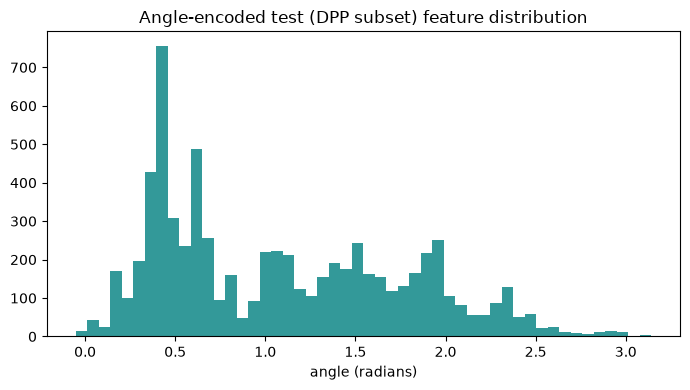

In [32]:
# raw -> scale -> optional pca -> [0, pi] using Day-23 train bounds
X_test_angles2 = to_angles(
    X_test2, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)

print(f"angles test: {X_test_angles2.shape}, | USE_PCA={USE_PCA}")

# cache DPP test subset (new angles -> one forward pass)
cache.compute(
    "test2",
    X_test_angles2,
    theta_star,
    forward_circuit,
    device=device,
    batch_size=batch_size,
    p=noise_rate,
    force=True,
)
print(f"[test2   ] n={cache.get('test2')['n']:,}")

fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))
ax1.hist(X_test_angles2.flatten(), bins=50, color="teal", alpha=0.8)
ax1.set_xlabel("angle (radians)")
ax1.set_title("Angle-encoded test (DPP subset) feature distribution")
plt.tight_layout()
plt.show()

In [33]:
y_pred2, radii2, novelty_scores2, f_maps2 = cached_qsnet_infer(
    cache.get("test2"),
    prototypes,
    q,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)
y_test_np2 = to_np_y(y_test2).astype(int)
label_ids = list(range(num_classes))

[test_bal] mean certified radius (accepted): 0.0360
[test_bal] reject rate (known): 0.1107 | acc (accepted): 0.5727

[test_bal] classification report (accepted only):
                precision    recall  f1-score   support

          DDoS       0.55      0.24      0.33       322
           DoS       0.42      0.82      0.56       341
        Normal       1.00      0.14      0.25       242
Reconnaissance       0.78      0.95      0.86       340

      accuracy                           0.57      1245
     macro avg       0.69      0.54      0.50      1245
  weighted avg       0.67      0.57      0.52      1245



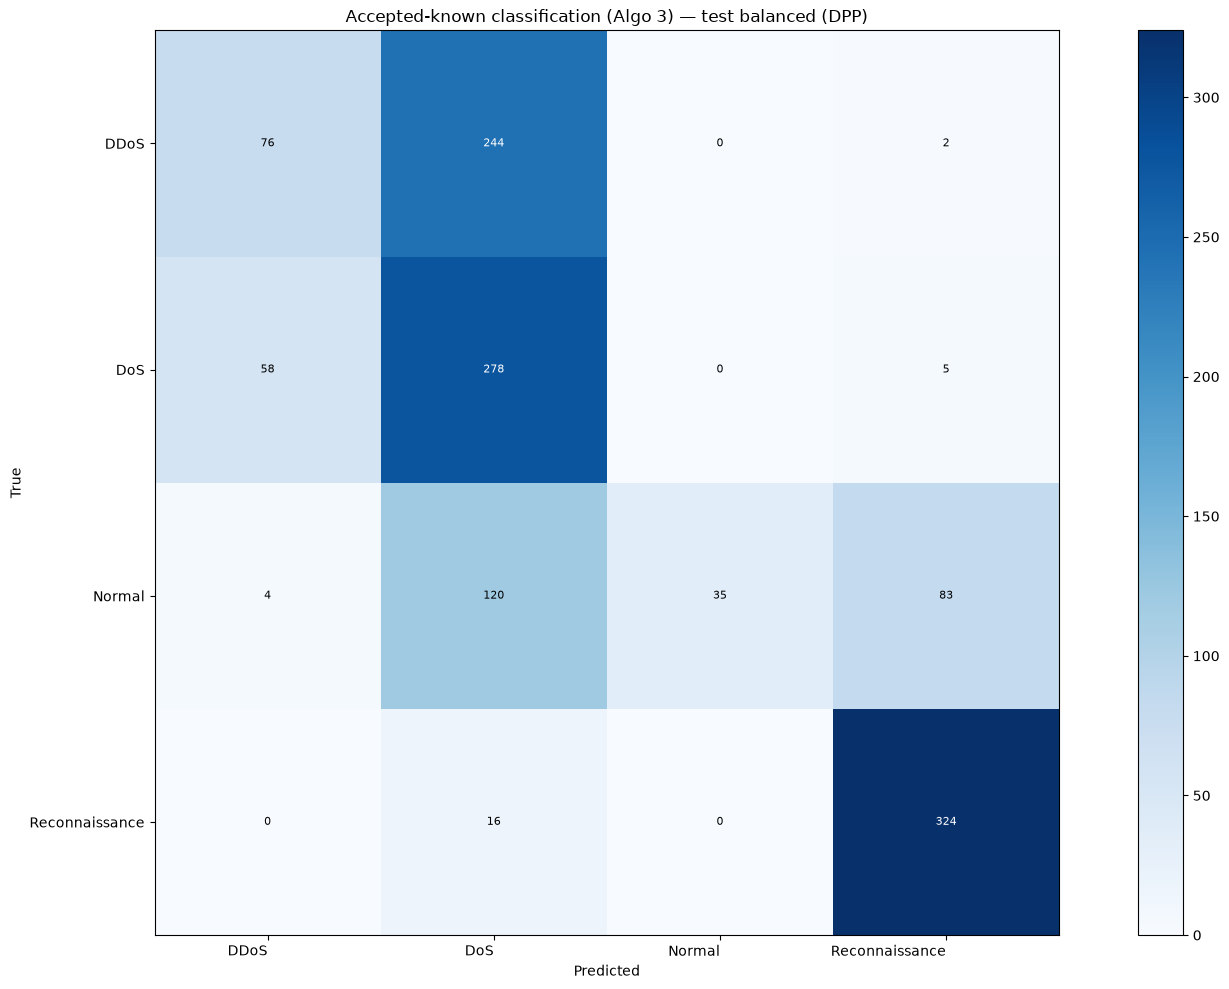

In [34]:
known_mask_test2 = y_pred2 != ZERO_DAY
test_bal_eval_rej_rate = float(1.0 - known_mask_test2.mean())
test_bal_eval_acc = (
    float(np.mean(y_pred2[known_mask_test2] == y_test_np2[known_mask_test2]))
    if known_mask_test2.any()
    else 0.0
)
test_bal_eval_macro_f1 = float(
    f1_score(
        y_test_np2[known_mask_test2],
        y_pred2[known_mask_test2],
        average="macro",
        labels=label_ids,
        zero_division=0,
    )
)
test_bal_eval_radius_mean = (
    float(radii2[known_mask_test2].mean()) if known_mask_test2.any() else float("nan")
)

print(f"[test_bal] mean certified radius (accepted): {test_bal_eval_radius_mean:.4f}")
print(
    f"[test_bal] reject rate (known): {test_bal_eval_rej_rate:.4f} | acc (accepted): {test_bal_eval_acc:.4f}"
)

if known_mask_test2.any():
    print("\n[test_bal] classification report (accepted only):")
    print(
        classification_report(
            y_test_np2[known_mask_test2],
            y_pred2[known_mask_test2],
            labels=label_ids,
            target_names=class_names,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_test_np2[known_mask_test2], y_pred2[known_mask_test2], labels=label_ids
    )

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3) — test balanced (DPP)",
    )
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Full Test Samples (No Reject Mask)

[test CE] accuracy (full set, no reject mask): 0.6473
[test CE] macro-F1 (full set): 0.6923
[test CE] n=18591

[test CE] classification report (full set):
                precision    recall  f1-score   support

          DDoS       0.73      0.55      0.62      9411
           DoS       0.60      0.73      0.66      8135
        Normal       0.52      0.97      0.67       691
Reconnaissance       0.71      0.94      0.81       354

      accuracy                           0.65     18591
     macro avg       0.64      0.79      0.69     18591
  weighted avg       0.67      0.65      0.64     18591



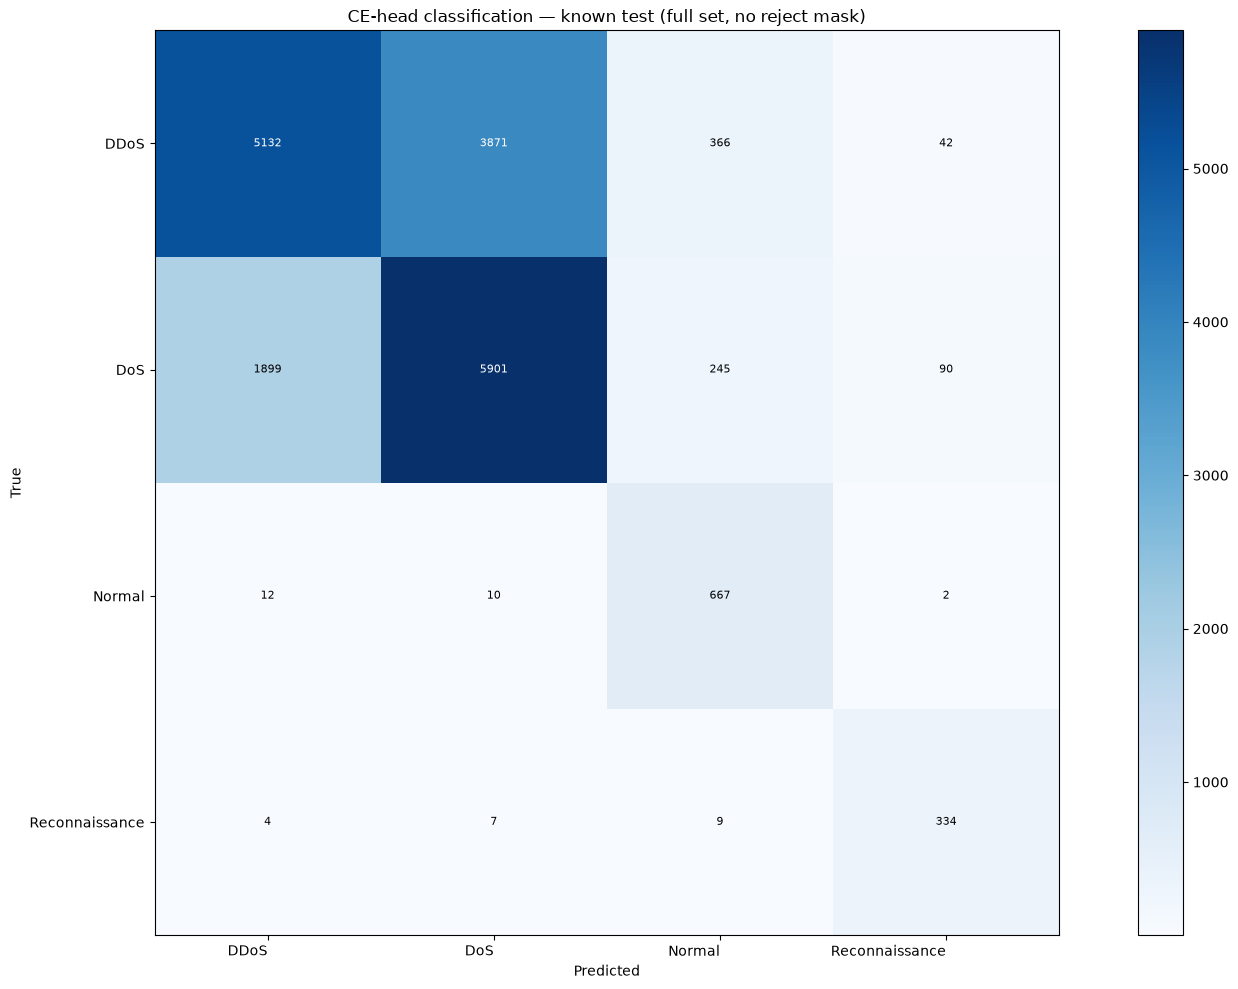

In [35]:
# CE-head labels on full known test (no Algo-3 reject mask)
if head is None:
    raise RuntimeError(
        "Day-23 checkpoint has no head_state_dict — cannot run CE full-test CM"
    )

y_true_ce, y_pred_ce = cached_predict_labels(
    cache.get("test"),
    y_test,
    head,
    device=device,
    batch_size=batch_size,
)
test_ce_acc = float(accuracy_score(y_true_ce, y_pred_ce))
test_ce_macro_f1 = float(
    f1_score(y_true_ce, y_pred_ce, average="macro", labels=label_ids, zero_division=0)
)

print(f"[test CE] accuracy (full set, no reject mask): {test_ce_acc:.4f}")
print(f"[test CE] macro-F1 (full set): {test_ce_macro_f1:.4f}")
print(f"[test CE] n={len(y_true_ce)}")
print("\n[test CE] classification report (full set):")
print(
    classification_report(
        y_true_ce,
        y_pred_ce,
        labels=label_ids,
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true_ce, y_pred_ce, labels=label_ids)

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted",
    ylabel="True",
    title="CE-head classification — known test (full set, no reject mask)",
)
plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=8,
        )
plt.tight_layout()
plt.show()

## Evaluation on Zero-Day Samples

Reuses Global zeroday branch (`labels_zday_g`). Detection rate under Global $q$ — not a multiclass CM.


In [36]:
df_zero_subset.head(3)

,n_pkts_total,n_bytes_total,src_bytes,rate,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,protocol,conn_state,label_multiclass
0,-1.441506,-1.957766,-3.072331,46.901080,0.000126,-0.863721,-0.609612,-0.274325,-1.0,-1.306571,Theft
1,-1.441506,-1.957766,-3.072331,47.759378,0.000108,-0.863728,-0.609621,-0.274325,-1.0,-1.306571,Theft
2,-1.441506,-1.957766,-3.072331,47.888686,0.000106,-0.863728,-0.609622,-0.274325,-1.0,-1.306571,Theft


In [37]:
print(
    f"detected as ZERO_DAY: {(y_zero_pred == ZERO_DAY).sum()} / {len(y_zero_pred)} ({detection_rate:.1%})"
)
print(f"incorrectly accepted: {(y_zero_pred != ZERO_DAY).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

detected as ZERO_DAY: 163 / 683 (23.9%)
incorrectly accepted: 520
mean novelty score: 0.2292 | threshold q: 0.2927


## Logging

In [38]:
out_dir = Path("artifacts") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "checkpoint": str(ckpt_path) if ckpt_path else None,
    "cache_path": str(cache_path) if "cache_path" in dir() else None,
    "inference_mode": "ForwardCache + Global/Mondrian cached infer",
    "lphi_path": lphi_path,
    "L_phi_source": "analytic_lipschitz_bound (R/2)",
    "q_source": q_source,
    "q": float(q),
    "alpha": float(alpha),
    "L_phi": float(L_phi),
    "p": float(p),
    "C_f": float(Cf),
    "use_pca": bool(USE_PCA),
    "num_qubits": int(num_qubits),
    "num_layers": int(num_layers),
    # split-level evals (Global q on train / full test / DPP coreset)
    "train_eval_rej_rate": float(train_eval_rej_rate),
    "train_eval_acc": float(train_eval_acc),
    "train_eval_macro_f1": float(train_eval_macro_f1),
    "train_eval_radius_mean": float(train_eval_radius_mean),
    "test_eval_rej_rate": float(test_eval_rej_rate),
    "test_eval_acc": float(test_eval_acc),
    "test_eval_macro_f1": float(test_eval_macro_f1),
    "test_eval_radius_mean": float(test_eval_radius_mean),
    "test_ce_acc": float(test_ce_acc),
    "test_ce_macro_f1": float(test_ce_macro_f1),
    "n_test_ce": len(y_true_ce),
    "test_bal_eval_rej_rate": float(test_bal_eval_rej_rate),
    "test_bal_eval_acc": float(test_bal_eval_acc),
    "test_bal_eval_macro_f1": float(test_bal_eval_macro_f1),
    "test_bal_eval_radius_mean": float(test_bal_eval_radius_mean),
    "zeroday_detection_rate": float(detection_rate),
    "n_zeroday_eval": len(X_zero),
    "chosen_strategy": CHOSEN_STRATEGY,
    "strategies": strategies,
    "RQ1": {
        "chosen_strategy": CHOSEN_STRATEGY,
        "TPR_zeroday": float(TPR_zeroday),
        "FPR_known": float(FPR_known),
        "class_acc_known": float(class_acc_known),
        "alpha": float(alpha),
        "n_test": len(y_test_np),
        "n_zeroday": len(X_zero),
        "strategies": strategies,
    },
    "global_vs_mondrian": {
        "chosen_strategy": CHOSEN_STRATEGY,
        "df_far": df_far.to_dict(orient="records"),
        "df_comparison": df_global_vs_mondrian.to_dict(orient="records"),
        "strategies": strategies,
    },
}
torch.save(artifact, out_dir / f"{NOTEBOOK_NAME}.pt")
print("published:", (out_dir / f"{NOTEBOOK_NAME}.pt").resolve())
print(f"chosen_strategy={CHOSEN_STRATEGY}")
for name, m in strategies.items():
    print(
        f"  {name}: chosen={m['chosen_as_strategy']}  "
        f"TPR={m['TPR_zeroday']:.4f}  FPR={m['FPR_known']:.4f}  "
        f"acc={m['class_acc_known']:.4f}"
    )

write_history_log(
    history if history else {"radius_mean": [test_eval_radius_mean]},
    NOTEBOOK_NAME,
    extra=artifact,
    log_dir="logs",
)

published: /home/lawun330/Desktop/quantum-sentinel/artifacts/BoT-IoT/4class-3000each-lr0.01auto-algo3-cached-algo3.pt
chosen_strategy=global
  global: chosen=True  TPR=0.2387  FPR=0.0471  acc=0.5208
  mondrian: chosen=False  TPR=0.2899  FPR=0.0367  acc=0.5260


PosixPath('logs/4class-3000each-lr0.01auto-algo3-cached.log')